In [8]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn requests

[✓] Loading local file: Telco-Customer-Churn.csv

Dataset shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...        

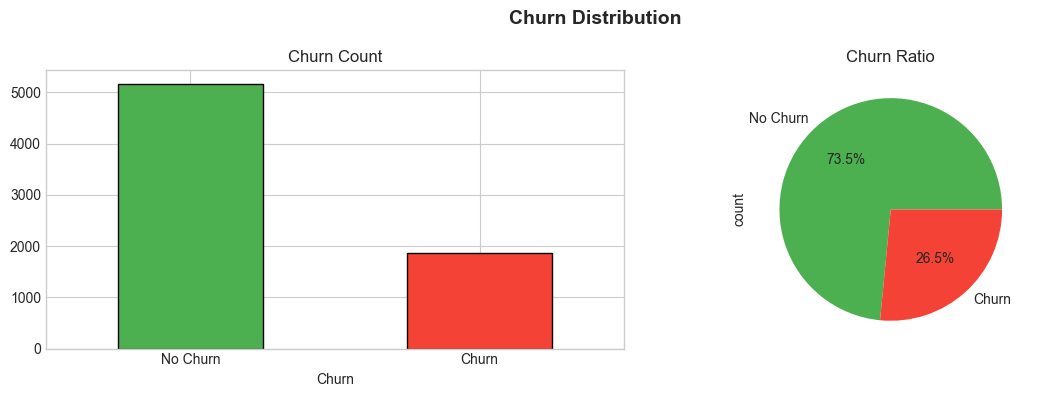

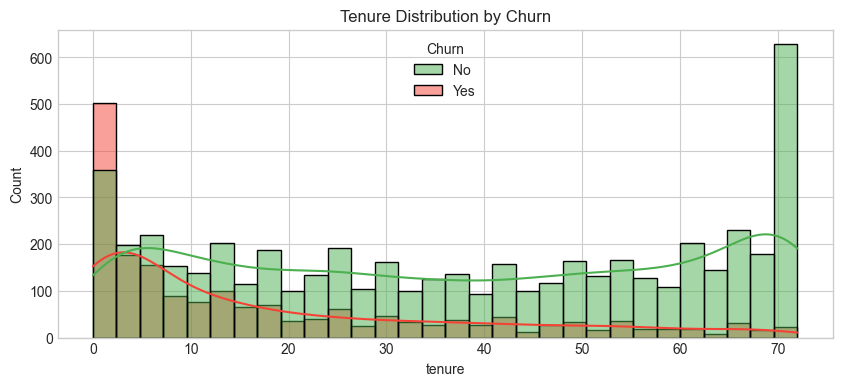

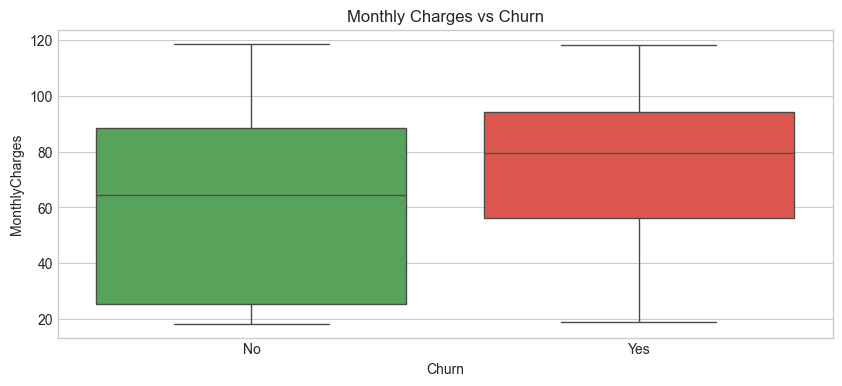


--- Cleaned Data Sample ---
   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0   

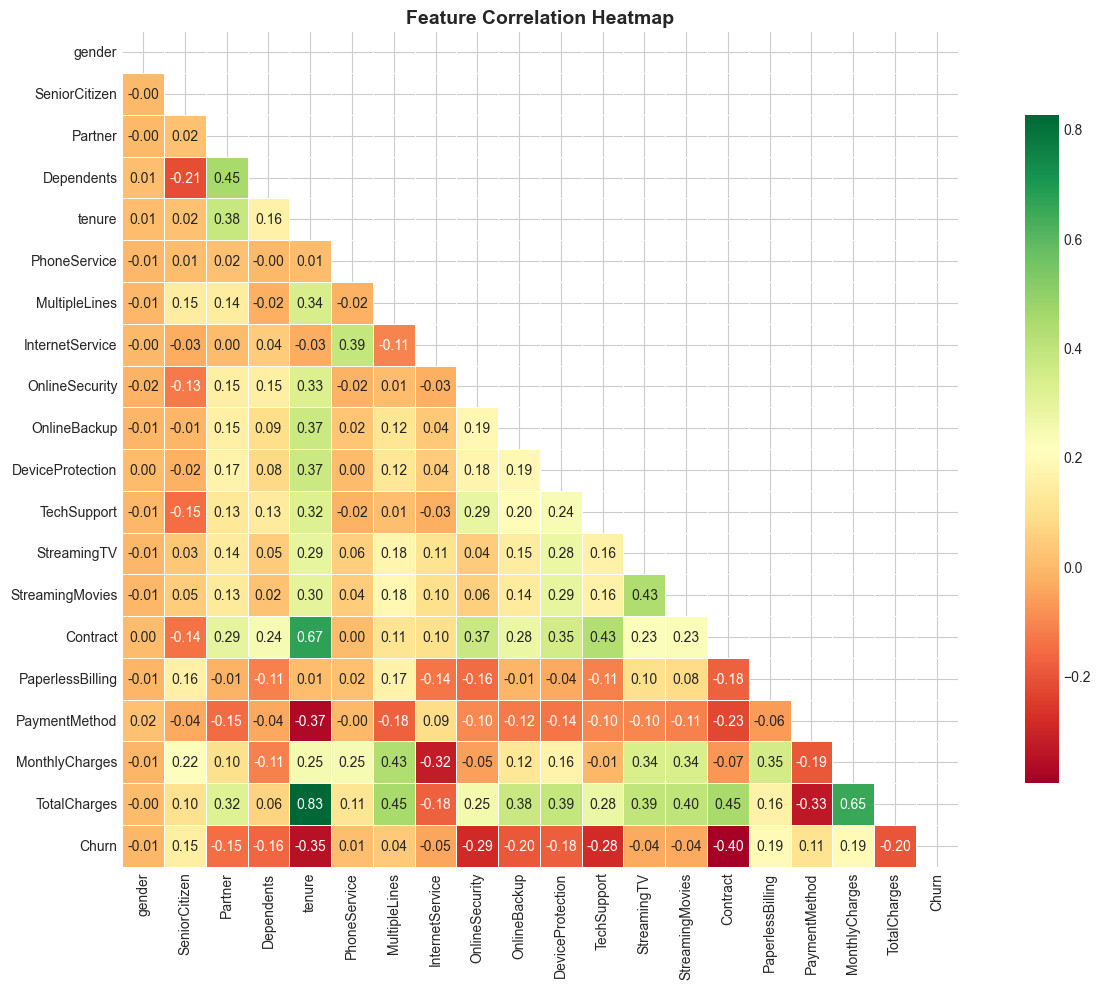


Train size: (5634, 19), Test size: (1409, 19)
Train churn rate: 26.54%

After SMOTE — Train size: (8278, 19)
Churn rate after SMOTE: 50.00%

  MODEL EVALUATION RESULTS

──────────────────────────────────────────────────
  Logistic Regression
──────────────────────────────────────────────────
  Accuracy  : 0.7516
  ROC-AUC   : 0.8223
  Precision : 0.5234
  Recall    : 0.7166
  F1-Score  : 0.6050
              precision    recall  f1-score   support

    No Churn       0.88      0.76      0.82      1035
       Churn       0.52      0.72      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409


──────────────────────────────────────────────────
  Decision Tree
──────────────────────────────────────────────────
  Accuracy  : 0.7651
  ROC-AUC   : 0.8109
  Precision : 0.5443
  Recall    : 0.7059
  F1-Score  : 0.6147
              precision    recall  f1-score   supp

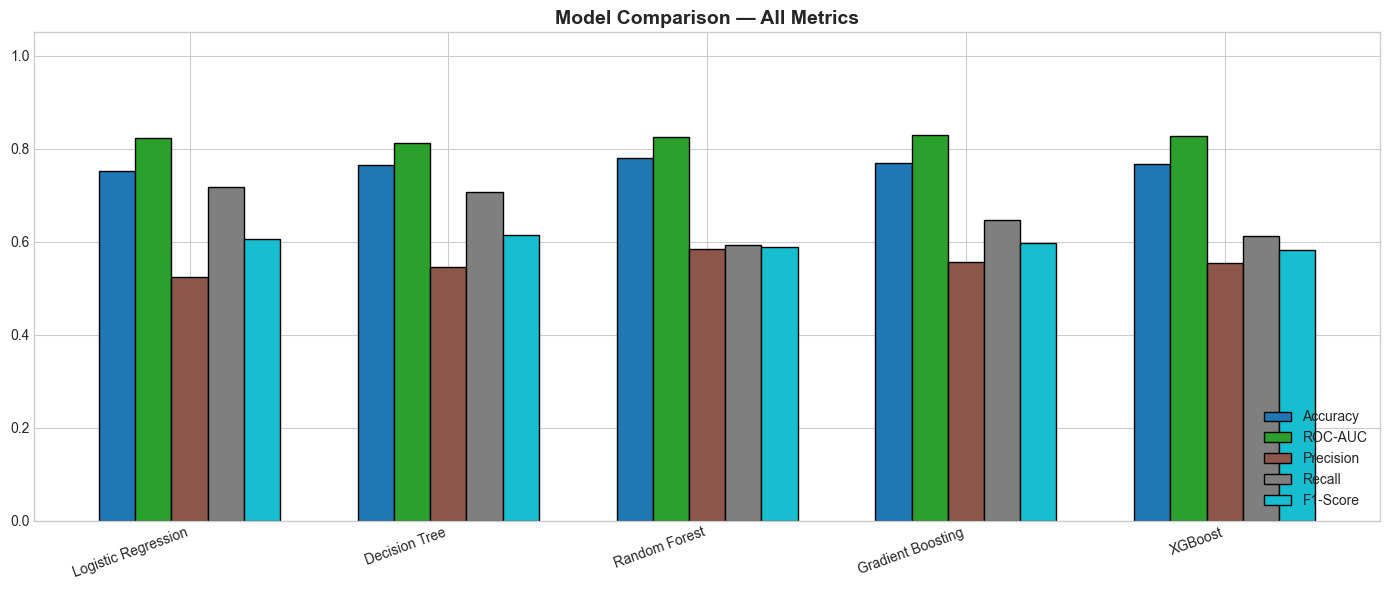

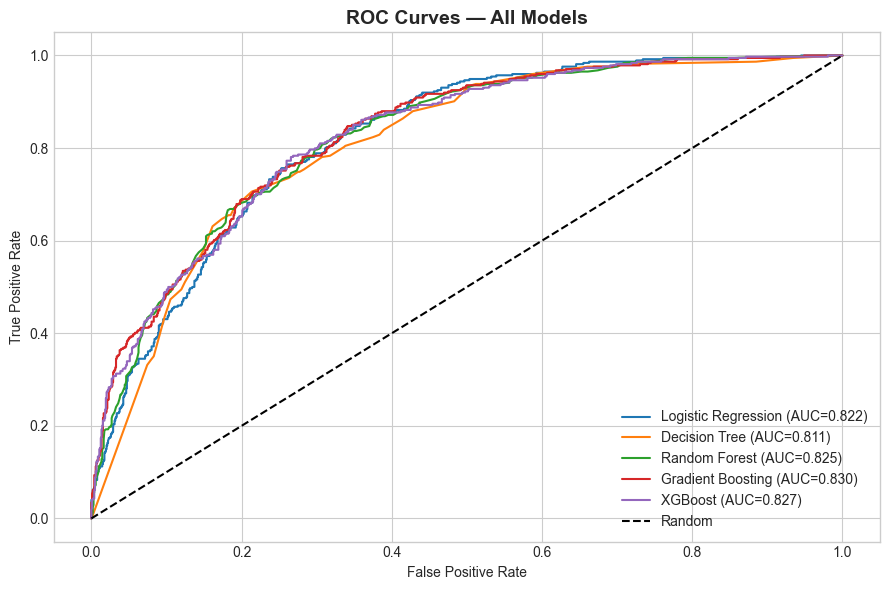


[★] Best Model by ROC-AUC: Gradient Boosting (0.8302)


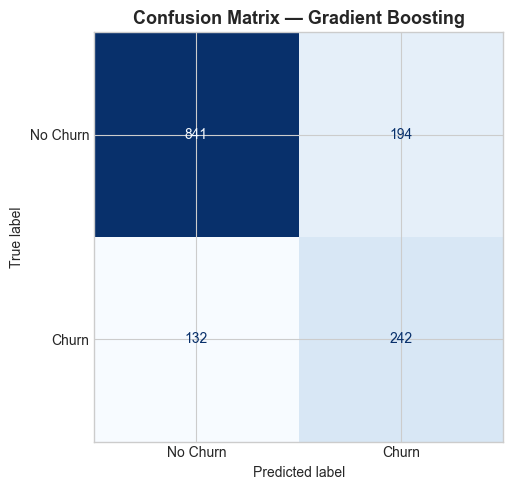

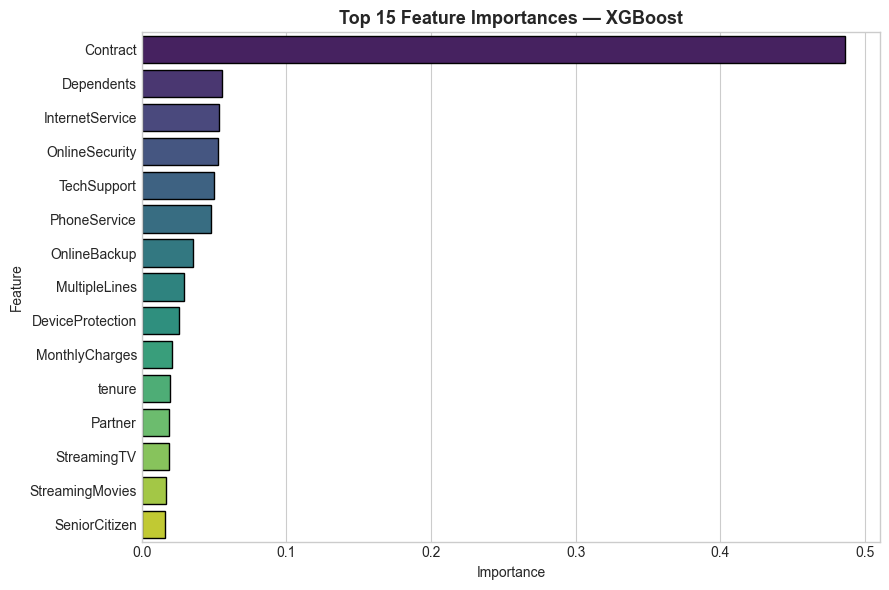


Top 10 Features (XGBoost):
         Feature  Importance
        Contract    0.486003
      Dependents    0.055160
 InternetService    0.053517
  OnlineSecurity    0.052481
     TechSupport    0.050092
    PhoneService    0.047899
    OnlineBackup    0.035543
   MultipleLines    0.029376
DeviceProtection    0.025811
  MonthlyCharges    0.020591

5-Fold Cross-Validation ROC-AUC (Gradient Boosting):
  Scores : [0.8565 0.8024 0.8085 0.8069 0.8146]
  Mean   : 0.8178
  Std    : 0.0197

  SINGLE CUSTOMER CHURN PREDICTION
  Churn Probability : 1.59%
  Prediction        : WILL NOT CHURN
  Actual Label      : WILL NOT CHURN


In [9]:
import os, warnings, requests
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree             import DecisionTreeClassifier
from xgboost                  import XGBClassifier
from imblearn.over_sampling   import SMOTE

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# STEP 1 — Load Dataset (auto-download if not found)
# ============================================================

LOCAL_FILE = "Telco-Customer-Churn.csv"
REMOTE_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
    "/master/data/Telco-Customer-Churn.csv"
)

def load_data():
    if os.path.exists(LOCAL_FILE):
        print(f"[✓] Loading local file: {LOCAL_FILE}")
        return pd.read_csv(LOCAL_FILE)
    print("[↓] Local file not found — downloading dataset…")
    try:
        r = requests.get(REMOTE_URL, timeout=15)
        r.raise_for_status()
        with open(LOCAL_FILE, "wb") as f:
            f.write(r.content)
        print(f"[✓] Downloaded and saved as {LOCAL_FILE}")
        return pd.read_csv(LOCAL_FILE)
    except Exception as e:
        raise RuntimeError(
            f"Auto-download failed ({e}).\n"
            f"Please download manually from:\n  https://www.kaggle.com/datasets/blastchar/telco-customer-churn\n"
            f"and place '{LOCAL_FILE}' in the same directory."
        )

df = load_data()
print(f"\nDataset shape: {df.shape}")
print(df.head())


# ============================================================
# STEP 2 — Exploratory Data Analysis (EDA)
# ============================================================

print("\n--- Basic Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())
print("\n--- Churn Distribution ---")
print(df["Churn"].value_counts())

# --- Plot 1: Churn distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["Churn"].value_counts().plot(kind="bar", ax=axes[0], color=["#4CAF50", "#F44336"],
                                  edgecolor="black", title="Churn Count")
axes[0].set_xticklabels(["No Churn", "Churn"], rotation=0)
df["Churn"].value_counts().plot(kind="pie", ax=axes[1], autopct="%1.1f%%",
                                  colors=["#4CAF50", "#F44336"],
                                  labels=["No Churn", "Churn"], title="Churn Ratio")
plt.suptitle("Churn Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("01_churn_distribution.png", dpi=150)
plt.show()

# --- Plot 2: Tenure vs Churn ---
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, palette=["#4CAF50", "#F44336"])
plt.title("Tenure Distribution by Churn")
plt.savefig("02_tenure_distribution.png", dpi=150)
plt.show()

# --- Plot 3: Monthly Charges vs Churn ---
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", palette=["#4CAF50", "#F44336"])
plt.title("Monthly Charges vs Churn")
plt.savefig("03_monthly_charges.png", dpi=150)
plt.show()


# ============================================================
# STEP 3 — Preprocessing
# ============================================================

df_clean = df.copy()

# Drop customerID (not a feature)
df_clean.drop(columns=["customerID"], inplace=True)

# Fix TotalCharges (has spaces → convert to numeric)
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"].fillna(df_clean["TotalCharges"].median(), inplace=True)

# Encode binary target
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# Encode all object columns with LabelEncoder
le = LabelEncoder()
cat_cols = df_clean.select_dtypes(include="object").columns
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

print("\n--- Cleaned Data Sample ---")
print(df_clean.head())

# --- Correlation heatmap ---
plt.figure(figsize=(14, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
            linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("04_correlation_heatmap.png", dpi=150)
plt.show()


# ============================================================
# STEP 4 — Feature / Target Split + Train-Test Split
# ============================================================

X = df_clean.drop(columns=["Churn"])
y = df_clean["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}")


# ============================================================
# STEP 5 — Handle Class Imbalance with SMOTE
# ============================================================

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train size: {X_train_sm.shape}")
print(f"Churn rate after SMOTE: {y_train_sm.mean():.2%}")


# ============================================================
# STEP 6 — Model Training (5 Models)
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled  = scaler.transform(X_test)

models = {
    "Logistic Regression":    LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":          DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":          RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting":      GradientBoostingClassifier(n_estimators=150, learning_rate=0.1, random_state=42),
    "XGBoost":                XGBClassifier(n_estimators=200, learning_rate=0.05,
                                             use_label_encoder=False, eval_metric="logloss",
                                             random_state=42, n_jobs=-1),
}

results = {}

print("\n" + "="*60)
print("  MODEL EVALUATION RESULTS")
print("="*60)

for name, model in models.items():
    # Use scaled data for Logistic Regression; raw for tree models
    Xtr = X_train_scaled if name == "Logistic Regression" else X_train_sm
    Xte = X_test_scaled  if name == "Logistic Regression" else X_test

    model.fit(Xtr, y_train_sm)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    roc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    results[name] = {
        "model":     model,
        "y_pred":    y_pred,
        "y_prob":    y_prob,
        "roc_auc":   roc,
        "accuracy":  report["accuracy"],
        "precision": report["1"]["precision"],
        "recall":    report["1"]["recall"],
        "f1":        report["1"]["f1-score"],
    }

    print(f"\n{'─'*50}")
    print(f"  {name}")
    print(f"{'─'*50}")
    print(f"  Accuracy  : {report['accuracy']:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"  Precision : {report['1']['precision']:.4f}")
    print(f"  Recall    : {report['1']['recall']:.4f}")
    print(f"  F1-Score  : {report['1']['f1-score']:.4f}")
    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


# ============================================================
# STEP 7 — Compare Models Visually
# ============================================================

metrics_df = pd.DataFrame({
    name: {
        "Accuracy":  v["accuracy"],
        "ROC-AUC":   v["roc_auc"],
        "Precision": v["precision"],
        "Recall":    v["recall"],
        "F1-Score":  v["f1"],
    }
    for name, v in results.items()
}).T

print("\n--- Model Comparison Table ---")
print(metrics_df.round(4))

# Bar chart comparison
ax = metrics_df.plot(kind="bar", figsize=(14, 6), colormap="tab10", edgecolor="black", width=0.7)
plt.title("Model Comparison — All Metrics", fontsize=14, fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("05_model_comparison.png", dpi=150)
plt.show()


# ============================================================
# STEP 8 — ROC Curves 
# ============================================================

plt.figure(figsize=(9, 6))
for name, v in results.items():
    fpr, tpr, _ = roc_curve(y_test, v["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={v['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("06_roc_curves.png", dpi=150)
plt.show()


# ============================================================
# STEP 9 — Best Model: Confusion Matrix
# ============================================================

best_name = max(results, key=lambda n: results[n]["roc_auc"])
best      = results[best_name]
print(f"\n[★] Best Model by ROC-AUC: {best_name} ({best['roc_auc']:.4f})")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, best["y_pred"]),
    display_labels=["No Churn", "Churn"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("07_confusion_matrix_best.png", dpi=150)
plt.show()


# ============================================================
# STEP 10 — Feature Importance 
# ============================================================

tree_models = ["XGBoost", "Random Forest", "Gradient Boosting"]
fi_model_name = next((n for n in tree_models if n in results), None)

if fi_model_name:
    fi_model = results[fi_model_name]["model"]
    fi_df = pd.DataFrame({
        "Feature":   X.columns,
        "Importance": fi_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=fi_df, x="Importance", y="Feature",
                palette="viridis", edgecolor="black")
    plt.title(f"Top 15 Feature Importances — {fi_model_name}",
              fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("08_feature_importance.png", dpi=150)
    plt.show()

    print(f"\nTop 10 Features ({fi_model_name}):")
    print(fi_df.head(10).to_string(index=False))


# ============================================================
# STEP 11 — Cross-Validation 
# ============================================================

best_model  = best["model"]
cv_X = X_test_scaled if best_name == "Logistic Regression" else X_test.values
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, cv_X, y_test, cv=cv, scoring="roc_auc")

print(f"\n5-Fold Cross-Validation ROC-AUC ({best_name}):")
print(f"  Scores : {np.round(cv_scores, 4)}")
print(f"  Mean   : {cv_scores.mean():.4f}")
print(f"  Std    : {cv_scores.std():.4f}")


# ============================================================
# STEP 12 — Predict on New Customer 
# ============================================================

sample_customer = X_test.iloc[[0]]       # take first test row as example
sample_scaled   = scaler.transform(sample_customer) if best_name == "Logistic Regression" else sample_customer

churn_prob  = best_model.predict_proba(sample_scaled)[0][1]
churn_label = "WILL CHURN" if churn_prob >= 0.5 else "WILL NOT CHURN"

print("\n" + "="*50)
print("  SINGLE CUSTOMER CHURN PREDICTION")
print("="*50)
print(f"  Churn Probability : {churn_prob:.2%}")
print(f"  Prediction        : {churn_label}")
print(f"  Actual Label      : {'WILL CHURN' if y_test.iloc[0]==1 else 'WILL NOT CHURN'}")
print("="*50)


In [10]:
!git init

Reinitialized existing Git repository in C:/Users/user/.git/


In [11]:
!git config --global user.email "mittallaxmi12@gmail.com"
!git config --global user.name "laxmimittal"

In [9]:
!git add .

fatal: Unable to create 'C:/Users/user/.git/index.lock': File exists.

Another git process seems to be running in this repository, e.g.
an editor opened by 'git commit'. Please make sure all processes
are terminated then try again. If it still fails, a git process
may have crashed in this repository earlier:
remove the file manually to continue.


In [11]:
!git commit -m "Add customer churn prediction ML project"

fatal: Unable to create 'C:/Users/user/.git/index.lock': File exists.

Another git process seems to be running in this repository, e.g.
an editor opened by 'git commit'. Please make sure all processes
are terminated then try again. If it still fails, a git process
may have crashed in this repository earlier:
remove the file manually to continue.


In [13]:
!git remote add origin https://github.com/laxmimittal/Machine_Learning_Based_Customer_Churn_Detecton_Model.git

error: remote origin already exists.


In [15]:
!git branch -M main

In [17]:
!git push -u origin main

branch 'main' set up to track 'origin/main'.


Everything up-to-date
